# Clustering

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score, adjusted_rand_score

from src.plotting_functions import *
from src.column_spec import ColumnSpec
from src.clustering import *
from src.filters import *

In [24]:
# hme1_1      = pd.read_csv("../../Experiment/hme1_1/Data/Processed/20260505_hTERT_HME1_1_processes_phosphoPlus.tsv", sep="\t").fillna(0)
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260714_hTERT_HEM1_2_processed_phPlus.tsv", sep="\t", low_memory=False)
# hek_1       = pd.read_csv("../../Experiment/hek_1/Data/Processed/20260505_HEK293T_raw_selection_processes_phosphoPlus.tsv", sep="\t").fillna(0)
# hme1_mutants = pd.read_csv(
#     "../../Experiment/hme1_mutants_test/Data/Processed/20260505_hTERT_HME1_mutants_test_processed_phosphoPlus_filtered.tsv", sep="\t").fillna(0)

## Parameters

Edit the cell below to change the dataset, conditions, and k-scan settings.
All downstream cells read from these variables.

In [27]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the full analysis
# ════════════════════════════════════════════════════════════

df_raw = hme1_2                      # dataset to cluster

CELL_LINES   = ["WT"]   # ["WT", "BRAFS151A", "GAB1Y259A"]
CONDITIONS   = ["_EGF_"]  # ["_EGF_", "_INS_", "_EGFnINS_"]
DATA_TYPE    = "log2:zscore"
EXCLUDE_FULL = True

# Filtering
MIN_REPS = 2
MIN_FC   = 0.5                       # |log2FC| threshold (extremes mode)

# K-scan
K_RANGE  = range(5, 31, 5)           # k values to test: 5, 10, 15, 20, 25, 30
N_SEEDS  = 5                         # random seeds for stability estimate
MAX_ITER = 200                       # max iterations per run during the scan
N_INIT   = 5                         # number of initializations per k

# Final clustering (set after inspecting the k-scan summary)
K_FINAL     = 15
CLUSTER_COL = f"KMeans_{K_FINAL}clusters"

# ── Derived — do not edit ────────────────────────────────────────────────────
_scan_cols   = ColumnSpec.select(df_raw, cell_lines=CELL_LINES, data_type=DATA_TYPE,
                                  conditions=CONDITIONS, exclude_full=EXCLUDE_FULL,
                                  exclude_replicate_cols=True)
N_DIMS       = len(CELL_LINES) * len(CONDITIONS)
N_TIMEPOINTS = len(_scan_cols) // N_DIMS
print(f"Columns selected: {len(_scan_cols)}  |  Dimensions: {N_DIMS}  |  Timepoints per condition: {N_TIMEPOINTS}")

Columns selected: 6  |  Dimensions: 1  |  Timepoints per condition: 6


# Filtering data

In [26]:
df_filtered = filter_by_nreps(df_raw, min_reps=MIN_REPS)
print(f"After n:reps >= {MIN_REPS}:  {df_filtered.shape[0]} sites")

df_filtered = filter_dynamics(
    df           = df_filtered,
    cell_lines   = CELL_LINES,
    conditions   = CONDITIONS,
    data_type    = DATA_TYPE,
    threshold    = MIN_FC,
    mode         = "extremes",
    exclude_full = EXCLUDE_FULL,
)
print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

After n:reps >= 2:  33719 sites
After |FC| >= 0.5:      33719 sites


## filtering LFQ dataset

In [ ]:
# Remove rows without PTM
df_filtered = df_raw[df_raw.assigned_modifications_clean.notna()]
print(f"Original size: {df_raw.shape}")

# Drop rows where site is not detected in the starvation control
df_filtered = df_filtered[df_filtered["WT_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["BRAFS151A_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["GAB1Y259A_raw:abs_EGF_starve_r1"] != 0]

raw_columns = [element for element in df_raw.columns if 'raw' in element]

print(f"Dataframe after removing sites with no starve detected: {df_filtered.shape}")
replicates = [element for element in raw_columns if "starve" not in element and "cv" not in element and "mean" not in element and "median" not in element and "sd" not in element]
# print(f"Raw columns of time points replicates: {replicates}")

replicates = list(set([element.replace("_r1", "").replace("_r2", "") for element in replicates]))

suffixes = ["_r1", "_r2"]

# Drop rows if the phosphosite was not detected in the 2 replicates for any time point and any condition
for condition in replicates:
    mask = (
        (df_filtered[f"{condition}{suffixes[0]}"] == 0) &
        (df_filtered[f"{condition}{suffixes[1]}"] == 0)
    )
    df_filtered = df_filtered.drop(df_filtered[mask].index)

print(f"Dataframe after removing sites where a site is missing in the two replivates: {df_filtered.shape}")

df_filtered = filter_dynamics(
    df           = df_filtered,
    cell_lines   = CELL_LINES,
    conditions   = CONDITIONS,
    data_type    = DATA_TYPE,
    threshold    = MIN_FC,
    mode         = "extremes",
    exclude_full = EXCLUDE_FULL,
)
print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

## K-scan — finding the optimal number of clusters

For each k in `K_RANGE` and each random seed the loop collects:
- **Inertia** — total within-cluster DTW distance (seed 0). Lower = tighter. Look for an elbow.
- **Silhouette** — how much closer each site is to its own cluster than to the nearest other (seed 0, precomputed DTW matrix). Range ~0–1; 0.2–0.4 is typical for phosphoproteomics.
- **Stability** — mean pairwise ARI across all seed pairs. Higher = more reproducible at this k.

To use a different algorithm swap `clustering_fn` below:
- `tslearn_clustering_KShape` — drop the `metric` key from `clustering_kwargs`
- `kernnel_clustering` — rename `number_of_clusters` → `n_clusters` and `random_state` → `seed` in the loop call

In [ ]:
# ── Clustering function ─────────────────────────────────────────────────────
# Swap this line to test a different algorithm (see markdown above).
clustering_fn = tslearn_clustering_KMeans

# Generate a dictionary with all the variables that are going to be used in the clustering algorithms this way you do not have to repeat the same values everywhere
clustering_kwargs = dict(
    data_type                = DATA_TYPE,
    condition_for_clustering = CONDITIONS,
    cell_lines               = CELL_LINES,
    exclude_full             = EXCLUDE_FULL,
    df_dimensions            = N_DIMS,
    time_series_length       = N_TIMEPOINTS,
    transpose                = True,
    max_iterations           = MAX_ITER,
    n_init                   = N_INIT,
    metric                   = "euclidean",  # remove this line when using KShape
    verbose                  = False,
    testing                  = True,         # must be True to get model + multivariate
)

# ── Scan loop ────────────────────────────────────────────────────────────────
inertias, silhouettes, stabilities = [], [], []

for k in K_RANGE:
    labels_list = []

    for seed in range(N_SEEDS):
        _, model, multivariate = clustering_fn(
            df_to_cluster       = df_filtered.copy(),
            cluster_column_name = f"_kscan_k{k}_s{seed}",
            number_of_clusters  = k,
            random_state        = seed,
            **clustering_kwargs,
        )
        labels_list.append(model.labels_)

        if seed == 0:
            inertias.append(model.inertia_)
            D   = cdist_dtw(multivariate)
            sil = silhouette_score(D, model.labels_, metric="precomputed")
            silhouettes.append(sil)

    ari_scores = [
        adjusted_rand_score(labels_list[i], labels_list[j])
        for i in range(len(labels_list))
        for j in range(i + 1, len(labels_list))
    ]
    stabilities.append(np.mean(ari_scores))
    print(f"k={k:3d}  inertia={inertias[-1]:.4f}  silhouette={silhouettes[-1]:.4f}  stability={stabilities[-1]:.4f}")

In [ ]:
fig, axes = plot_kscan_summary(K_RANGE, inertias, silhouettes, stabilities)
plt.show()

### Load k-scan results from the server

The scripts in `scripts/` run the same k-scan in parallel on the calculation server and write a TSV with columns `k`, `inertia`, `silhouette`, `stability` — named `{prefix}_qc_metrics_{conditions}.tsv`.

Point `SERVER_RESULT` at one of those files to plot the full server scan instead of (or alongside) the local one above.

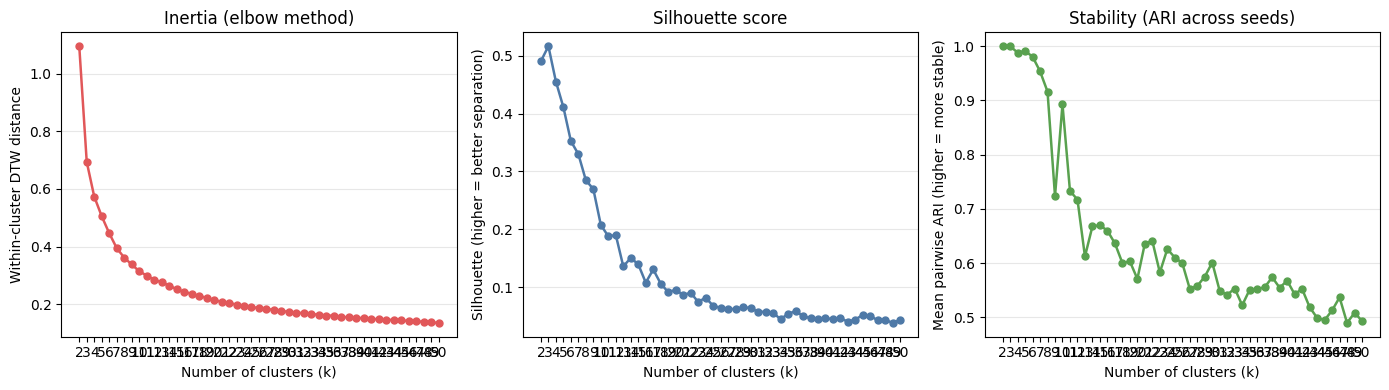

In [7]:
SERVER_RESULT = "../../Server/Server_results/20260310_calculations/20260310_kmeans_50clusters_qc_metrics_EGF.tsv"

server_df = pd.read_csv(SERVER_RESULT, sep="\t")

fig, axes = plot_kscan_summary(
    ks          = server_df["k"],
    inertias    = server_df["inertia"],
    silhouettes = server_df["silhouette"],
    stabilities = server_df["stability"],
)
plt.show()

## Final clustering

Set `K_FINAL` in the Parameters cell after inspecting the k-scan summary, then run this section.

In [28]:
df_clustered, clustering_model, multivariate, barycenters = tslearn_clustering_KMeans(
    df_to_cluster            = df_filtered.copy(),
    data_type                = DATA_TYPE, #DATA_TYPE, "log2:FC"
    condition_for_clustering = CONDITIONS,
    cell_lines               = CELL_LINES,
    exclude_full             = EXCLUDE_FULL,
    stoichiometry            = None,
    cluster_column_name      = CLUSTER_COL,
    number_of_clusters       = K_FINAL,
    max_iterations           = 1000,
    n_init                   = 10,
    metric                   = "euclidean",
    df_dimensions            = N_DIMS,
    time_series_length       = N_TIMEPOINTS,
    random_state             = 0,
    transpose                = False,
    verbose                  = True,
    testing                  = True,
    barycenter_calculations  = True,
)
print(f"\nCluster sizes:\n{df_clustered[CLUSTER_COL].value_counts().sort_index()}")

Column selection: ['WT_log2:zscore_EGF_starve', 'WT_log2:zscore_EGF_2', 'WT_log2:zscore_EGF_5', 'WT_log2:zscore_EGF_10', 'WT_log2:zscore_EGF_15', 'WT_log2:zscore_EGF_90']

Reshaping dataframe to shape (33719, 1, 6)

The size of the dataset is (33719, 1, 6)
Example:
[[-0.8654722  -0.91489251 -0.2370491   0.31066903 -0.43062677 -0.11275489]]
Init 1
1.163 --> 0.984 --> 0.956 --> 0.944 --> 0.937 --> 0.933 --> 0.931 --> 0.929 --> 0.928 --> 0.927 --> 0.927 --> 0.926 --> 0.926 --> 0.925 --> 0.925 --> 0.925 --> 0.925 --> 0.924 --> 0.924 --> 0.924 --> 0.924 --> 0.923 --> 0.923 --> 0.923 --> 0.922 --> 0.922 --> 0.921 --> 0.921 --> 0.921 --> 0.920 --> 0.920 --> 0.920 --> 0.919 --> 0.919 --> 0.919 --> 0.919 --> 0.918 --> 0.918 --> 0.918 --> 0.918 --> 0.918 --> 0.918 --> 0.918 --> 0.918 --> 0.917 --> 0.917 --> 0.917 --> 0.917 --> 0.917 --> 0.917 --> 0.917 --> 0.916 --> 0.916 --> 0.916 --> 0.916 --> 0.916 --> 0.916 --> 0.915 --> 0.915 --> 0.915 --> 0.915 --> 0.915 --> 0.914 --> 0.914 --> 0.914 --> 0

In [29]:
fig, ax = plot_sites_umap_interactive(df_clustered,
                                    cell_lines=["WT"], #"WT", "BRAFS151A", "GAB1Y259A"],
                                    conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
                                    data_type="log2:zscore",
                                    exclude_full=True,
                                    color_col=CLUSTER_COL, # None  "protein_name"
                                    hover_cols=None,
                                    n_neighbors=15,
                                    min_dist=0.1,
                                    random_state=42,
                                    figsize=(1000, 800),
                                    title=None,
)


fig.show()

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Cluster visualization

 Plot not saved


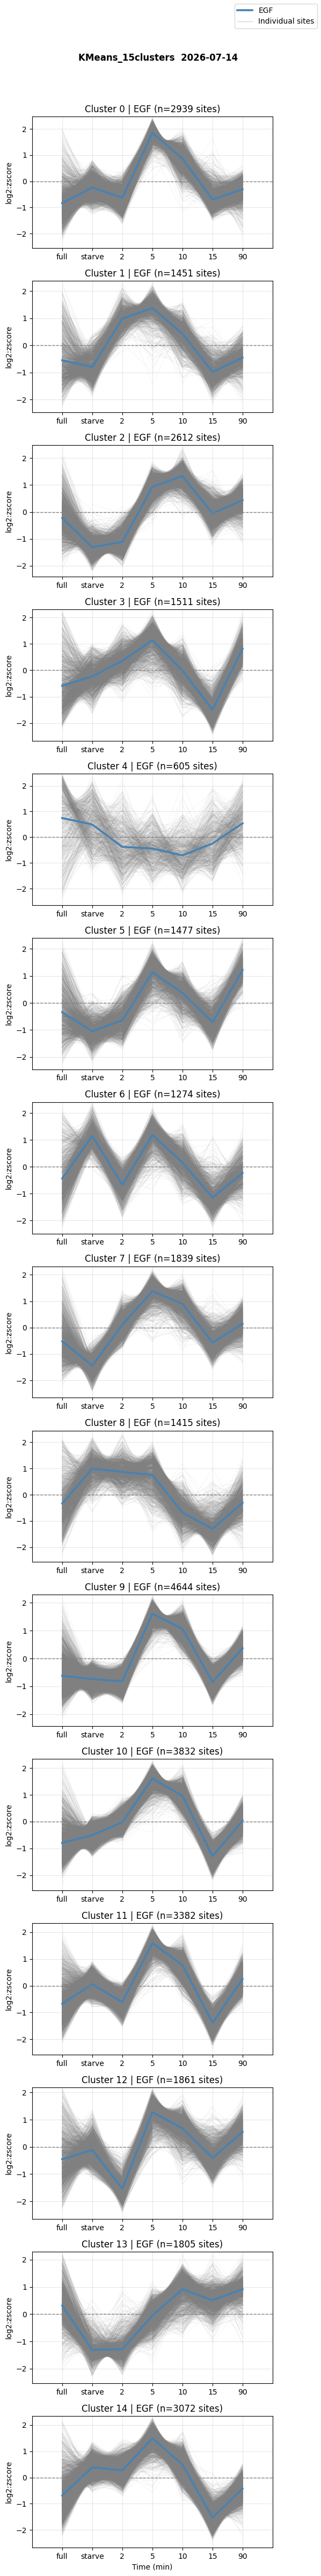

In [30]:
clusters_plot_linear_mutants(
    df                  = df_clustered,
    cluster_column      = CLUSTER_COL,
    data_type           = "log2:zscore", # DATA_TYPE, "log2:FC"  "log2:scaled"
    cell_lines          = CELL_LINES,
    conditions          = CONDITIONS,
    colors              = {"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"}, # {"_EGF_": "red", "_INS_": "blue", "_EGFnINS_": "pink"}, {"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"}
    panel_by            = "condition", # condition cell_line
    plot_different_data = True,
    legend              = None,
    saving_path         = "",
    saving_info         = "",
    save_pdf            = False,
    save_png            = False,
    plot_close          = False,
    fit_y_lims          = False,
    grey_alpha          = 0.08,
    grey_lw             = 0.8,
    mean_lw             = 2.6,
)

## Cluster quality — within-cluster Euclidean dispersion

Lower bars mean tighter (more homogeneous) clusters per condition. Distance is measured point-by-point (Euclidean); since all sites share the same fixed timepoints this is appropriate and much faster than DTW.

In [33]:
scores = cluster_similarity_per_condition(
    df                  = df_clustered,
    cell_lines          = CELL_LINES,
    conditions          = CONDITIONS,
    data_type           = DATA_TYPE,
    cluster_column_name = CLUSTER_COL,
    exclude_full        = EXCLUDE_FULL,
    transpose           = True,
    # metric              = "DTW",  # euclideanmetric not needed anymore because i am going to use always euclidean, as time series are aligned
)
fig, ax = plot_cluster_scores(
    scores,
    cond_order = [c.strip("_") for c in CONDITIONS],
    title      = f"Within-cluster Euclidean dispersion — {CLUSTER_COL}",
)
plt.show()

KeyboardInterrupt: 

## Assignment confidence

Four views of how confidently each site was assigned to its cluster:

- **Distance-to-centroid heatmap** — rows are sites (sorted by cluster), columns are clusters; the assigned cluster should be the darkest cell in each row.
- **UMAP** — 2-D embedding of the distance-to-centroid matrix coloured by cluster; tight, well-separated blobs indicate clean assignments.
- **Margin histogram** — margin = (2nd-best distance) − (best distance); higher margin = more confident assignment. The orange line marks the 25th percentile (low-confidence sites).
- **Margin per cluster (boxplot)** — reveals which clusters are internally tight vs. ambiguous.

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


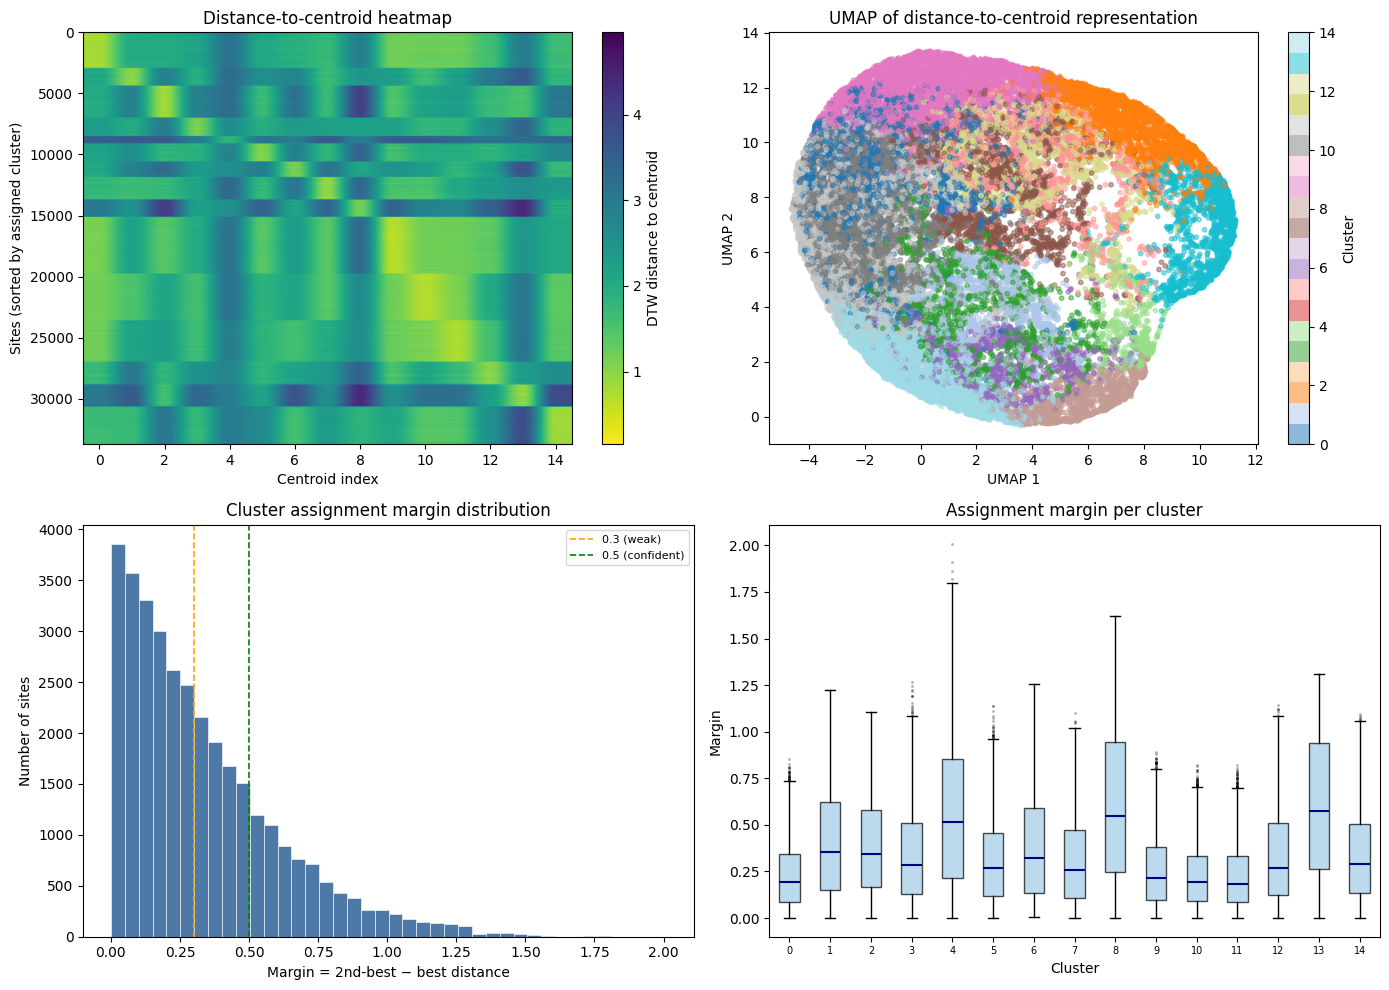

In [34]:
fig, axes = plot_cluster_assignment_qc(barycenters, clustering_model.labels_)
plt.show()

## Cluster hierarchy

KMeans assigns sites to clusters but gives them no inherent order.  This section imposes structure on the result by computing pairwise DTW distances **between the cluster centroids** and running hierarchical clustering on those distances.

Two outputs:
- **Dendrogram** — shows which KMeans clusters are similar to each other and at what DTW distance they merge into super-clusters.  Use the colour threshold to read off natural groupings.
- **Centroid grid** — the same centroid profiles as the cluster visualisation above, but rows are sorted by dendrogram leaf order so similar clusters appear adjacent.  The line colour matches the dendrogram super-cluster colour.

Useful for deciding whether to merge nearby clusters after the k-scan, and for producing a clean ordered summary of the final result.

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/src/plotting_functions.py:1455: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, n_timepoints - 1)


IndexError: list index out of range

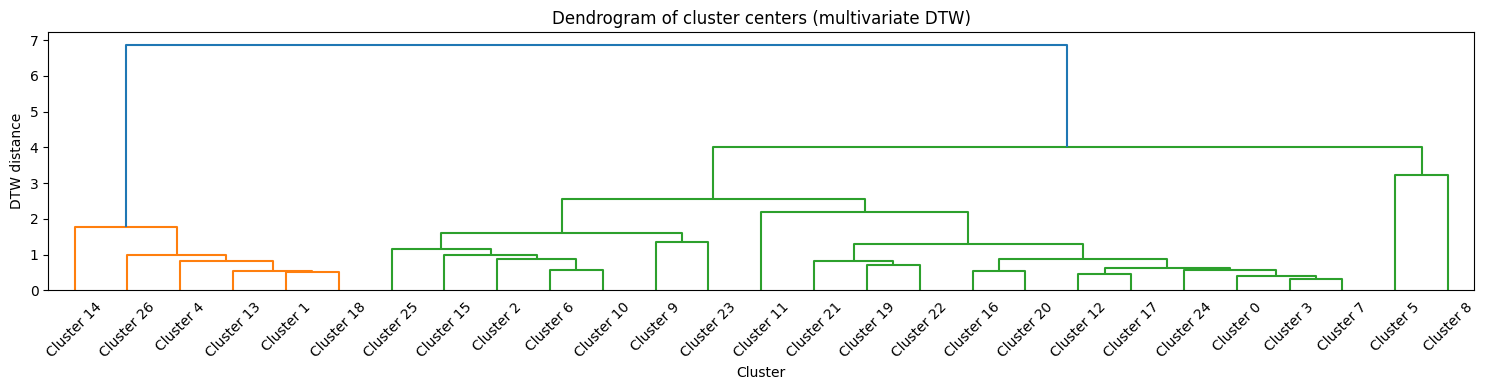

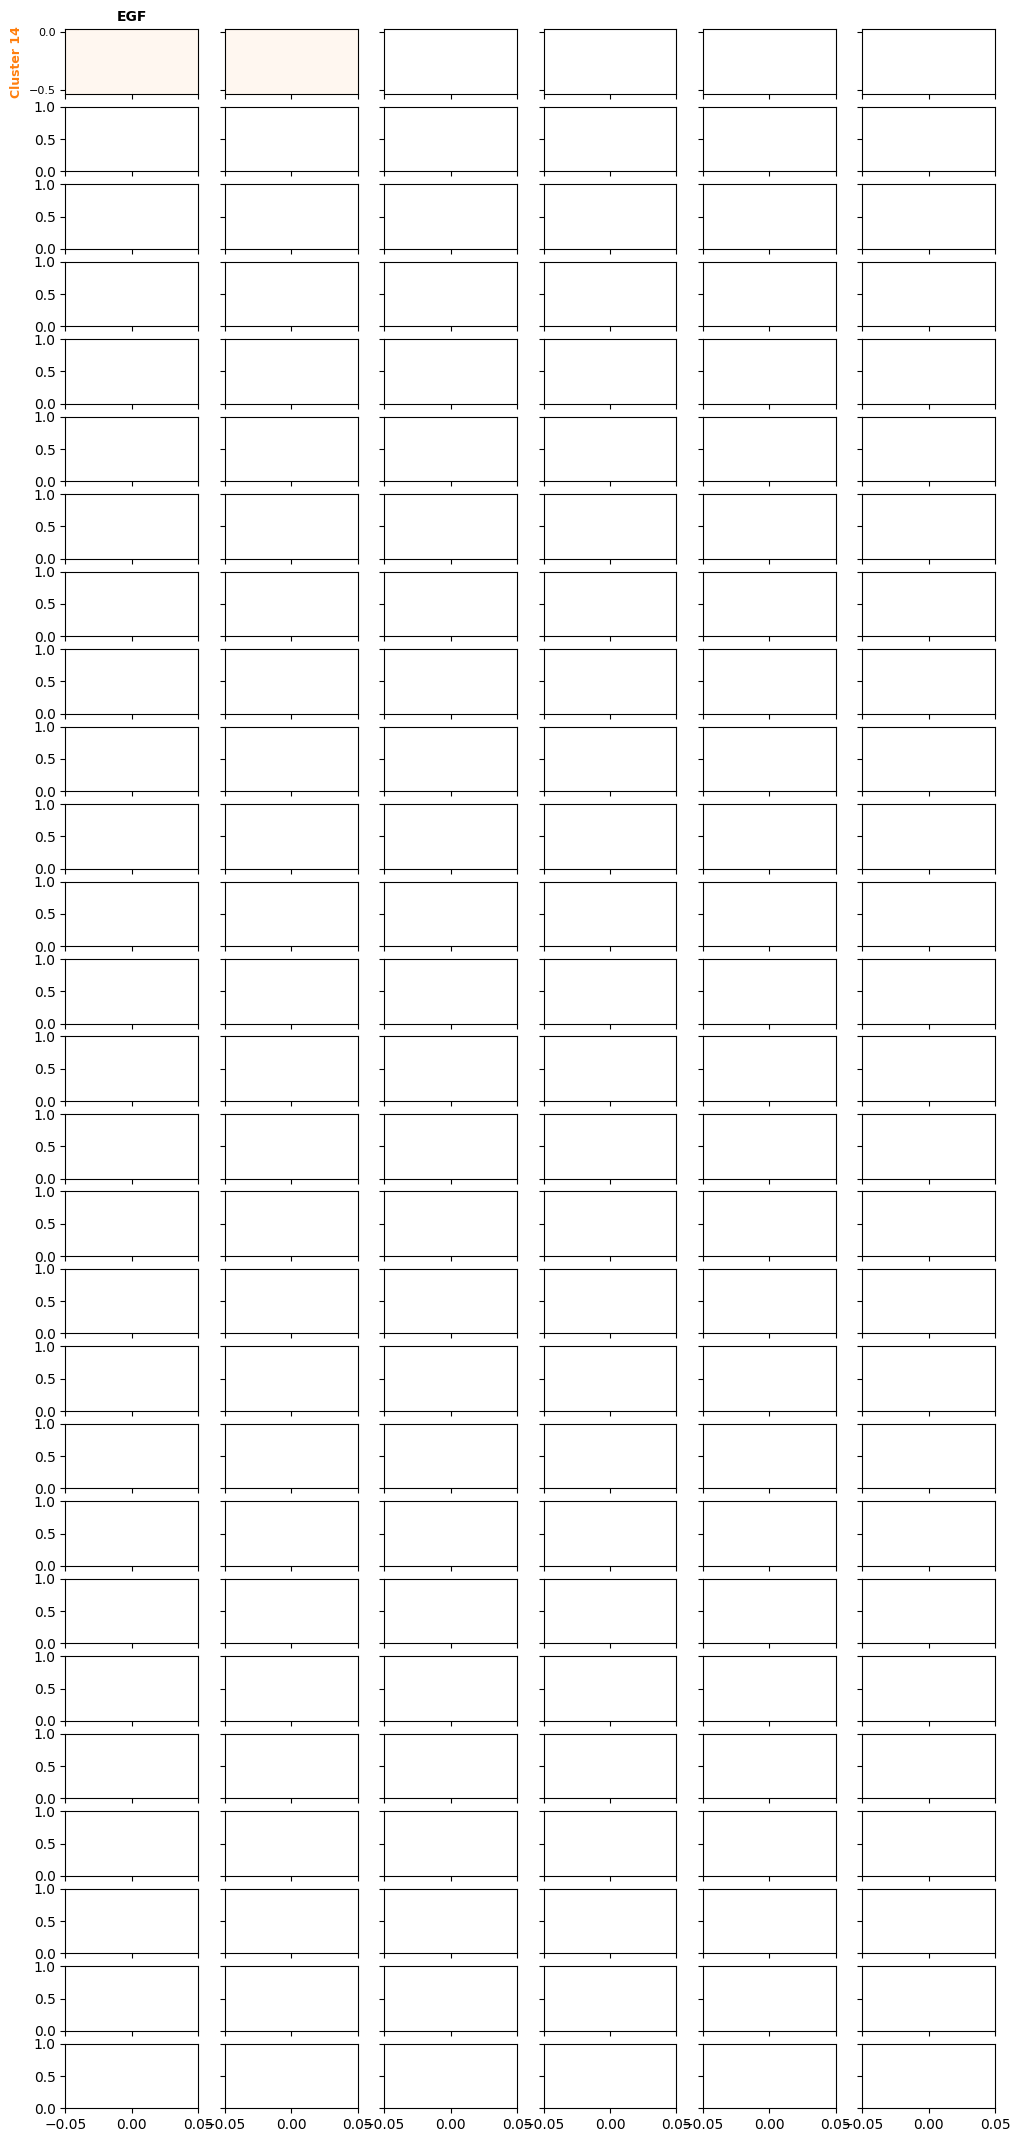

In [22]:
from src.clustering import compute_centroid_linkage

Z_hier, dist_matrix = compute_centroid_linkage(
    centers = clustering_model.cluster_centers_,
    method  = "weighted",
)

fig_dendro, fig_grid = plot_cluster_hierarchy(
    centers         = clustering_model.cluster_centers_,
    Z               = Z_hier,
    condition_names = [c.strip("_") for c in CONDITIONS],
    color_threshold = 0.7,
)
plt.show()